In [52]:
import numpy as np
import matplotlib.pyplot as plt
from pillow_lab_rotation import lds
from importlib import reload
inv = np.linalg.inv
plt.style.use('../JS.mplstyle')

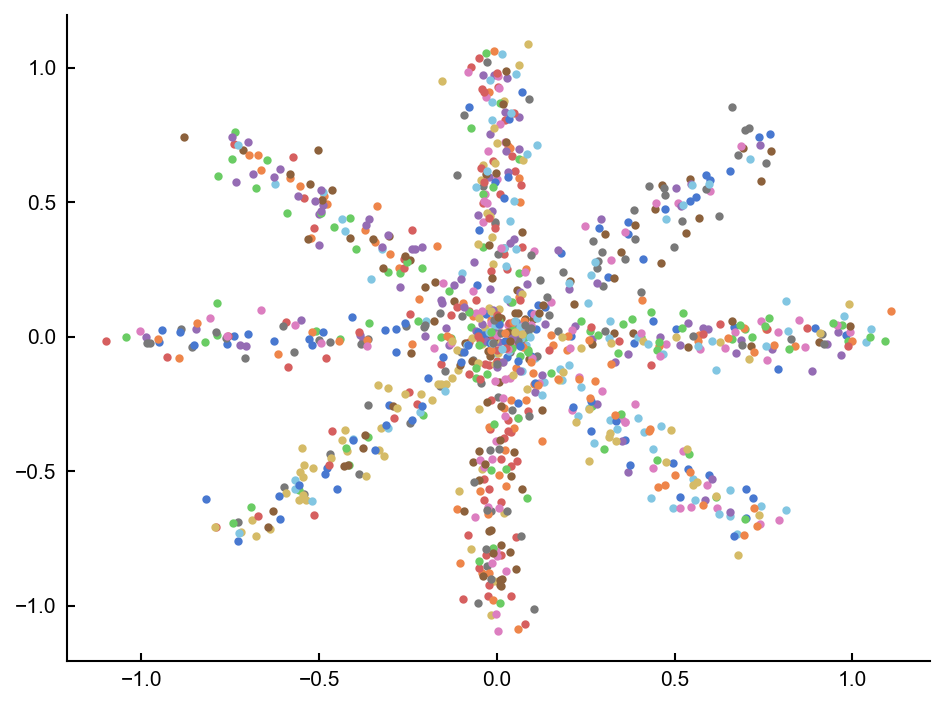

In [53]:
thetas = np.deg2rad(np.linspace(0, 360, 9))[:-1]
n_trials = 100
noise = 0.05
T = 10
r = np.linspace(0, 1, T)
X = np.zeros((n_trials, T, 2, 1))
for n in range(n_trials):
    theta = np.random.choice(thetas)
    # for i, theta in enumerate(thetas):
    x = r * np.cos(theta) + np.random.normal(0, noise, T)
    y = r * np.sin(theta) + np.random.normal(0, noise, T)
    X[n] = np.array([x, y]).T[..., None]
    plt.plot(x, y,  '.')

In [54]:
reload(lds)

<module 'pillow_lab_rotation.lds' from '/Users/jeremyschroeter/Desktop/the-ark/phd/rotations/pillow_lab_rotation/src/pillow_lab_rotation/lds.py'>

In [55]:
lds_model = lds.LinearDynamicalSystem(2, 2)

In [56]:
lds_model.fit(X)

In [57]:
pred_means, pred_covs, obs_mean, obs_cov, post_means, post_covs = lds_model.predict(X)

In [58]:
from pillow_lab_rotation.plotting import plot_confidence_ellipse

/Users/jeremyschroeter/Desktop/the-ark/phd/rotations/pillow_lab_rotation/src/pillow_lab_rotation/plotting.py:55: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(contour_1[:,0], contour_1[:,1], 'b-', linewidth=0.5, c='k')
/Users/jeremyschroeter/Desktop/the-ark/phd/rotations/pillow_lab_rotation/src/pillow_lab_rotation/plotting.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(contour_2[:,0], contour_2[:,1], 'b-', linewidth=0.5, c='k')


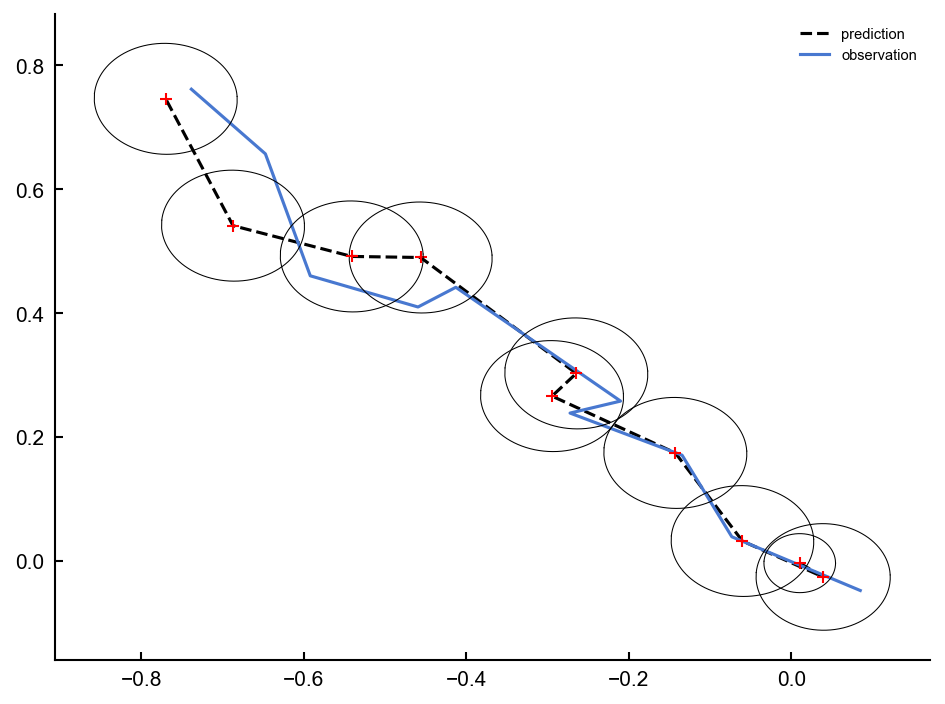

In [59]:

trial = 12

plt.plot(obs_mean[trial, :, 0, 0], obs_mean[trial, :, 1, 0], linestyle='--', label='prediction', c='k')
plt.plot(X[trial, :, 0, 0], X[trial, :, 1, 0], label='observation')
for t in range(T):
    plot_confidence_ellipse(obs_mean[trial, t, :, 0], obs_cov[trial, t])

plt.legend()

In [60]:
X.shape

(100, 10, 2, 1)

In [61]:
X[40, :, 0].shape

(10, 1)